# Baseline Model (Decision Tree) notebook

## Libraries

In [21]:
# Import libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [22]:
df = pd.read_csv("data/corona_tested_individuals_ver_006.csv", low_memory=False)
# df['test_date'] = pd.to_datetime(df['test_date'], dayfirst=True)

# df = pd.read_csv("data/corona_tested_individuals_ver_0083.english.zip", low_memory=False, compression="zip")

df = df[df["corona_result"] != "other"]



In [23]:
# Undersample negative corona_result cases to make the data more balanced
df_positive = df[df["corona_result"]=="positive"]
df_negative = df[df["corona_result"]=="negative"]

df = pd.concat([df_positive, df_negative.sample(n=len(df_positive))], axis=0) 

train, test = train_test_split(df, test_size=0.2, random_state=24, stratify=df["corona_result"])


In [24]:
df.head()

,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication
41,30/04/2020,1.0,0.0,0.0,0.0,0.0,positive,NaN,male,Contact with confirmed
43,30/04/2020,1.0,0.0,0.0,0.0,0.0,positive,NaN,female,Other
103,30/04/2020,0.0,0.0,0.0,0.0,0.0,positive,NaN,female,Contact with confirmed
120,30/04/2020,0.0,0.0,0.0,0.0,0.0,positive,NaN,male,Contact with confirmed
137,30/04/2020,1.0,1.0,0.0,0.0,0.0,positive,NaN,female,Other


**Question / Task 1**

Insert context about question / task 1 here.

In [25]:
# Add your code here


**Baseline model using only fever and cough as input features(decision tree)**

In [26]:
# Import necessary libraries for decision tree classifier and evaluation metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Define features (fever and cough) and target (corona_result)
features = ['fever', 'cough']
X_train = train[features]
y_train = train['corona_result']

X_test = test[features]
y_test = test['corona_result']

# Create and train the decision tree classifier
dt_model = DecisionTreeClassifier(random_state=24, max_depth=3)
dt_model.fit(X_train, y_train)

# Make predictions
y_train_pred = dt_model.predict(X_train)
y_test_pred = dt_model.predict(X_test)

# Evaluate the model
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print("\nConfusion Matrix (Test Set):")
print(confusion_matrix(y_test, y_test_pred))
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, zero_division=0))

Training Accuracy: 0.7215
Test Accuracy: 0.7105

Confusion Matrix (Test Set):
[[2493  453]
 [1253 1693]]

Classification Report (Test Set):
              precision    recall  f1-score   support

    negative       0.67      0.85      0.75      2946
    positive       0.79      0.57      0.66      2946

    accuracy                           0.71      5892
   macro avg       0.73      0.71      0.71      5892
weighted avg       0.73      0.71      0.71      5892



In [17]:
dt_model.feature_importances_

array([0.69852741, 0.30147259])

**Roc curve**

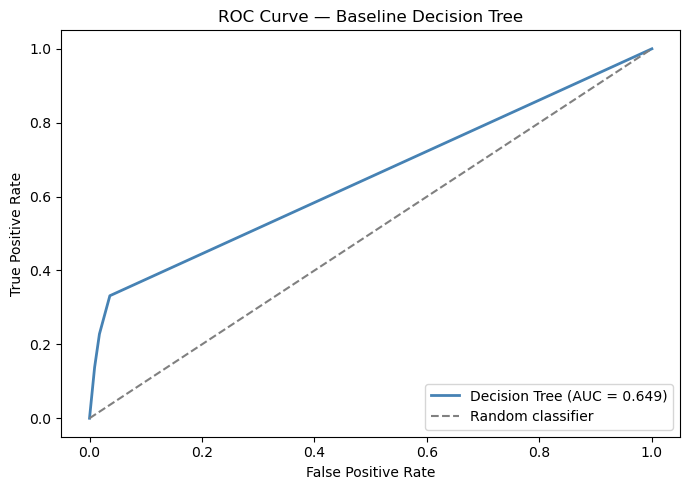

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities for the positive class
y_test_proba = dt_model.predict_proba(X_test)[:, list(dt_model.classes_).index('positive')]

# Compute ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba, pos_label='positive')
auc_score = roc_auc_score(y_test, y_test_proba)

# Plot the ROC curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'Decision Tree (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Baseline Decision Tree')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Baseline model using all features as input (decision tree)**

In [19]:
# Import necessary libraries for decision tree classifier and evaluation metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Define features (all except test_date and corona_result) and target
feature_cols = [c for c in df.columns if c not in ('corona_result', 'test_date')]

X_train_all = pd.get_dummies(train[feature_cols])
y_train = train['corona_result']

X_test_all = pd.get_dummies(test[feature_cols])
# Align columns in case train/test dummies differ
X_train_all, X_test_all = X_train_all.align(X_test_all, join='left', axis=1, fill_value=0)

# Create and train the decision tree classifier
dt_model_all = DecisionTreeClassifier(random_state=24, max_depth=3)
dt_model_all.fit(X_train_all, y_train)

# Make predictions
y_train_pred_all = dt_model_all.predict(X_train_all)
y_test_pred_all = dt_model_all.predict(X_test_all)

# Evaluate the model
train_accuracy_all = accuracy_score(y_train, y_train_pred_all)
test_accuracy_all = accuracy_score(y_test, y_test_pred_all)

print(f"Training Accuracy: {train_accuracy_all:.4f}")
print(f"Test Accuracy: {test_accuracy_all:.4f}")
print("\nConfusion Matrix (Test Set):")
print(confusion_matrix(y_test, y_test_pred_all))
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_all, zero_division=0))

Training Accuracy: 0.7833
Test Accuracy: 0.7837

Confusion Matrix (Test Set):
[[42359  1836]
 [17283 26912]]

Classification Report (Test Set):
              precision    recall  f1-score   support

    negative       0.71      0.96      0.82     44195
    positive       0.94      0.61      0.74     44195

    accuracy                           0.78     88390
   macro avg       0.82      0.78      0.78     88390
weighted avg       0.82      0.78      0.78     88390



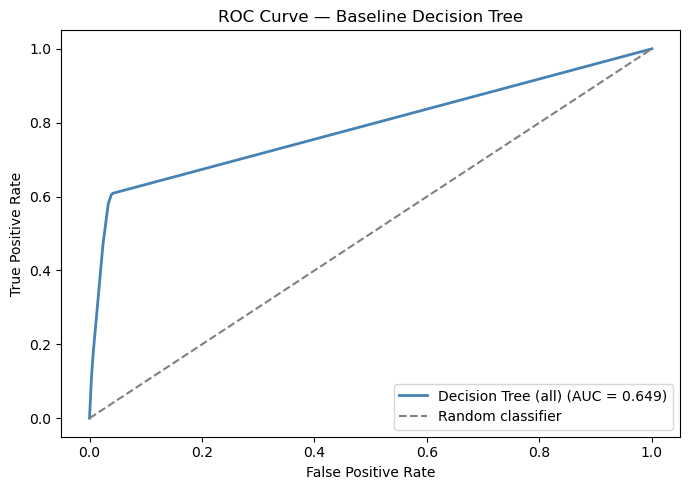

In [20]:
# Get predicted probabilities for the positive class
y_test_proba_all = dt_model_all.predict_proba(X_test_all)[:, list(dt_model_all.classes_).index('positive')]

# Compute ROC curve and AUC score
fpr_all, tpr_all, thresholds_all = roc_curve(y_test, y_test_proba_all, pos_label='positive')
auc_score_all = roc_auc_score(y_test, y_test_proba_all)

# Plot the ROC curve
plt.figure(figsize=(7, 5))
plt.plot(fpr_all, tpr_all, color='steelblue', lw=2, label=f'Decision Tree (all) (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Baseline Decision Tree')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()